# Laboratorium 2 — Zabójcze Zakręty

Ćwiczenie opiera się o instrukcję [Zakrety.pdf](Zakrety.pdf). Poniżej opisuję co robiłem krok po kroku (test losowy, tory b/c/d, studium parametrów, potem modyfikacje z PDF: pędzenie do przodu i wyłączenie IS). Do raportu doklejam jeszcze zrzuty tras i wykresów w oznaczonych miejscach.


## Krótko: założenia

Stan: pozycja + prędkość $(x,y,v_x,v_y)$, akcje to skoki przyspieszenia. Uczymy off-policy n-step SARSA: polityka docelowa to zachłanna względem $Q$, a behawioralna to albo ε-greedy, albo wersja „pędzenia”. Przy off-policy włączam importance sampling w wadze korekty (albo go wyłączam w jednym z eksperymentów).


## Opis problemu (z instrukcji)

Jedziemy po bitmapie: biały = tor, zielony = start, czerwony = meta. Każdy krok to kara −1, na mecie 0. Prędkości są ograniczone, czasem sterowanie się „wykrzacza” (`steering_fail_chance`). Wypadnięcie z trasy = reset prędkości i losowy start. Szczegóły w `problem.py`.


## Implementacja — off-policy n-step SARSA (`solution.py`)

W klasie `OffPolicyNStepSarsaDriver` trzymam ostatnie kroki w buforze (indeksowanie modulo `step_no+1`). W `control` jak mam już komplet pod aktualizację, liczę n-krokowy zwrot `G` i poprawiam $Q$ dla pary $(s_\tau, a_\tau)$. Ważny fragment:

```python
update_step = self.current_step - self.step_no + 1
if update_step >= 0:
    return_value_weight = self._return_value_weight(update_step)
    return_value = self._return_value(update_step)
    state_t = self.states[self._access_index(update_step)]
    action_t = self.actions[self._access_index(update_step)]
    self.q[state_t, action_t] += (
        self.step_size
        * return_value_weight
        * (return_value - self.q[state_t, action_t])
    )
```

Zwrot `G` składa się z nagród po drodze; jak trafię na koniec epizodu (nagroda 0), ucinam sumę. Jak nie ma końca w horyzoncie, dokładam bootstrap z $Q$ na końcu okna:

```python
for i in range(1, n + 1):
    r = float(self.rewards[self._access_index(tau + i)])
    g += (gamma ** (i - 1)) * r
    if r == 0.0:
        return g
s_h = self.states[self._access_index(tau + n)]
a_h = self.actions[self._access_index(tau + n)]
g += (gamma**n) * self.q[s_h, a_h]
```

Importance sampling: dla każdego kroku w oknie (bez pierwszego) mnożę $\rho \cdot= \pi(a|s)/b(a|s)$, gdzie $\pi$ jest greedy na $Q$, a $b$ to polityka behawioralna. Jak wyłączę IS, `_return_value_weight` zwraca po prostu 1.

```python
def _return_value_weight(self, update_step: int) -> float:
    if not self.use_importance_sampling:
        return 1.0
    rho = 1.0
    for k in range(tau + 1, tau + self.step_no):
        ...
        rho *= pi[ak] / b[ak]
    return rho
```

Trening jest w `train_off_policy(...)`; tryby uruchomienia ustawiam w `main()` (`train_b`, `train_c`, itd.).


## corner_b

`python solution.py train_b` — sprawdzenie czy na prostszym torze ucz się sensownie opada kara w czasie (domyślnie $\alpha=0.3$, $n=5$, $\varepsilon=0.05$ w `main`).

![corrner_b___track_800.png](corrner_b___track_800.png)

## Trasy przy zachłannej polityce (po uczeniu)

Podczas uczenia akcje są losowane z $b$ (eksploracja). Żeby pokazać jak agent jedzie przy **samej zachłannie** względem nauczonego $Q$, po treningu uruchamiam `GreedyPolicyDriver` (`run_greedy_rollouts`). Na obrazkach **`track_*.png`** widać bitmapę toru corner_b i **czerwone strzałki** — kolejne pozycje (środek auta) aż do mety lub limitu kroków.

```python
greedy_driver = GreedyPolicyDriver(q)
eval_exp = Experiment(
    environment=environment,
    driver=greedy_driver,
    number_of_episodes=n_episodes,
    draw_every_episode=True,
)
eval_exp.run()
```

Pliki poniżej: katalog `greedy_rollout_corner_b/`. Epizody **30001–30003** to zapisane przejazdy **zachłanne** (`run_greedy_rollouts`, offset epizodu w nazwie pliku).

![track_30001.png](greedy_rollout_corner_b/track_0.png)
![track_30001.png](greedy_rollout_corner_b/track_50.png)
![track_30001.png](greedy_rollout_corner_b/track_100.png)
![track_30001.png](greedy_rollout_corner_b/track_150.png)
**Bonus — jak wyglądało uczenie (nie sama zachłanność):** wykres `penalties_*.png` to skumulowana kara w czasie epizodów treningowych (uśrednienie w oknie); np. końcówka treningu przed greedy:

![penalties_50.png](greedy_rollout_corner_b/penalties_50.png)
![penalties_450.png](greedy_rollout_corner_b/penalties_450.png)
![penalties_450.png](greedy_rollout_corner_b/penalties_1350.png)
![penalties_5550.png](greedy_rollout_corner_b/penalties_5550.png)

Wszystkie kolejne wyglądają jak coraz bardziej wypłaszczona wersja tego wykresu

![penalties_26100.png](greedy_rollout_corner_b/penalties_26100.png)

## corner_c — studium $\alpha$ i $n$

`param_study` w `solution.py` odpala siatkę par $(n,\alpha)$ i zapisuje CSV do `case_study_SUCCESS/param_study_<tor>.csv`. Wykres generuje `utils.plot_param_study_n_alpha` albo polecenie `python solution.py param_study_plot --param-study-corner corner_c`. Na moich danych sensowny zakres to np. $n=4$ i $\alpha=0.5$ (widać na wykresie minimum).

Wykres studium (plik w `case_study_SUCCESS/` obok notatnika):

![param_study_corner_c.png](case_study_SUCCESS/param_study_corner_c.png)

Trasy corner_c (~550):

![corrner_c___track_550.png](corrner_c___track_550.png)

![corrner_c___track_550-2.png](corrner_c___track_550-2.png)

![corrner_c___track_550-3.png](corrner_c___track_550-3.png)


### Opcja: wykres z CSV (to samo co `param_study_plot`)

Jak mam CSV w `plots/`, mogę narysować wykres lokalnie zamiast wklejać PNG — albo obok siebie.


In [21]:
%pip install tqdm

import sys
from pathlib import Path

L2 = Path.cwd().resolve()
if not (L2 / "utils.py").is_file():
    for p in L2.parents:
        if (p / "utils.py").is_file():
            L2 = p
            break
if str(L2) not in sys.path:
    sys.path.insert(0, str(L2))

import utils

csv_path = L2 / "plots" / "param_study_corner_c.csv"
out_png = L2 / "plots" / "param_study_corner_c_notebook.png"
if csv_path.is_file():
    utils.plot_param_study_n_alpha(str(csv_path), str(out_png))
    print("Zapisano:", out_png)
else:
    print("Brak:", csv_path)


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\womackow\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Zapisano: C:\Users\womackow\Zbiorczy\_WIN_AI_AGH_\WIN_sem_1\UMISI-sem1-RL\l2\plots\param_study_corner_c_notebook.png


## corner_d

Na koniec odpalam najtrudniejszy tor z parametrami które wyszły wcześniej (u mnie $n=4$, $\alpha=0.5$). Wyniki zapisują się do `param_study_corner_d.csv` jak ustawię `corner` w `cmd_param_study`.


![corner_d/track_550.png](corner_d/track_550.png)


## Polityka „pędzenia do przodu” (corner_c)

Zamiast samego ε-greedy mieszam rozkład: część masy idzie na akcje z największym $a_x+a_y$ (bo tak „wciska gaz”), reszta zostaje przy ε-greedy na $Q$. Parametr `push_forward_bias` to właśnie ta mieszanka.

```python
def push_forward_policy(self, state: State, actions: list[Action]) -> dict[Action, float]:
    p = self.push_forward_bias
    accel_scores = np.array([float(a.a_x + a.a_y) for a in actions])
    max_s = float(np.max(accel_scores))
    push_mask = (accel_scores == max_s).astype(float)
    push = self._normalise(push_mask)
    greedy_mix = np.array(list(self.epsilon_greedy_policy(state, actions).values()))
    probs = p * push + (1.0 - p) * greedy_mix
    ...
```

Porównanie z rozsądnym $b$: `python solution.py compare_push_is` (u mnie ostatnio $\varepsilon$-greedy z IS wychodziło zdecydowanie lepiej niż push — średnia kara w oknie dla push szła w bardzo słabe wartości).

| konfiguracja | śr. kara (ostatnie 100 ep.) |
|--------------|----------------------------|
| epsilon_is | −117.03 |
| push_is | −505.0 |
| push_no_is | −505.0 |


## Wyłączenie IS przy pędzącym agencie

Wystarczy `use_importance_sampling=False` przy tworzeniu sterownika / w `train_off_policy`. Wtedy waga przy zwrocie to zawsze 1 i nie ma korekty $\pi/b$. Przy mocno innym $b$ niż $\pi$ bez IS uczymy się w praktyce na „złych” trajektoriach — u mnie przy push z IS i bez i tak wyszło źle w tym samym oknie, ale to już kwestia ustawień i liczby epizodów.



zapisano: C:\Users\womackow\Zbiorczy\_WIN_AI_AGH_\WIN_sem_1\UMISI-sem1-RL\l2\plots\compare_behavior_is.png


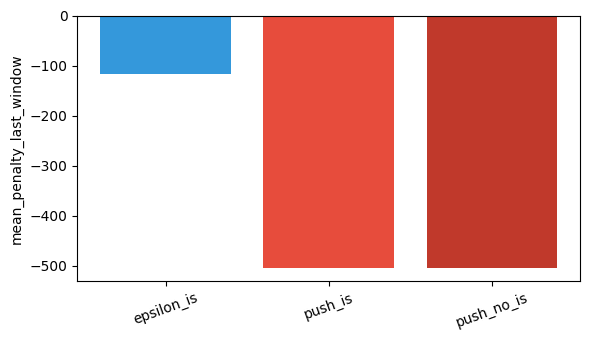

In [23]:
# opcjonalnie: słupki porównawcze z compare_behavior_is.csv
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

L2 = Path.cwd().resolve()
if not (L2 / "solution.py").is_file():
    for p in L2.parents:
        if (p / "solution.py").is_file():
            L2 = p
            break
PLOTS = L2 / "plots"

path = PLOTS / "compare_behavior_is.csv"
if path.is_file():
    df = pd.read_csv(path)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(df["name"], df["mean_penalty_last_window"], color=["#3498db", "#e74c3c", "#c0392b"])
    ax.set_ylabel("mean_penalty_last_window")
    plt.xticks(rotation=20)
    plt.tight_layout()
    out_bar = PLOTS / "compare_behavior_is.png"
    plt.savefig(out_bar, dpi=120, bbox_inches="tight")
    print("zapisano:", out_bar)
    plt.show()
else:
    print("brak", path)


## Wnioski

- **Środowisko i algorytm:** problem zakrętu sprowadza się do n-step SARSA poza polityką: zachłanna $\pi$ na $Q$, behawioralna $\varepsilon$-greedy (albo później „pędzenie”), z opcjonalnym importance sampling w wadze aktualizacji.

- **corner_b:** na prostym torze da się nauczyć rozsądnej polityki — na wykresach `penalties_*` widać poprawę średniej kary w czasie epizodów; po uczeniu **GreedyPolicyDriver** pokazuje krótkie, stabilne przejazdy (`track_30001` itd. w `greedy_rollout_corner_b/`), inne niż chaotyczny losowy start uczenia.

- **corner_c — studium $(n, \alpha)$:** zależność od hiperparametrów jest wyraźna (wykres `param_study_corner_c.png` / CSV): przy zbyt dużym $n$ krzywe się „psują”; sensowny punkt to okolica **$n=4$, $\alpha=0.5$**. Trasy na corner_c pokazują ten sam tor przy różnych przejazdach po wyuczeniu.

- **corner_d:** przy parametrach z poprzedniego kroku tor jest wyraźnie trudniejszy — to raczej weryfikacja niż „ładny” wynik od pierwszego strzału.

- **Polityka pędzenia:** mieszanka z preferencją dużego $a_x+a_y$ jako $b$ mocno rozjeżdża się od zachłannej $\pi$. Na corner_c w eksperymencie `compare_push_is` **$\varepsilon$-greedy z IS** pozostawał znośny, a warianty z **push** (z IS i bez) schodziły do praktycznie najgorszej kary w oknie — agresywne $b$ niszczy użyteczność danych w krótkim horyzoncie treningu. **Wyłączenie IS** przy push teoretycznie zabija korektę na $\pi$; w pomiarach i tak oba warianty były złe, więc główny winowajca to tu sam wybór $b$.